# Torus vs Klein bottle — telling them apart by persistent homology

Both surfaces share the same Betti vector over $\mathbb{Z}/2$: $\beta = (1, 2, 1)$.
They differ over $\mathbb{Z}/3$ (or any field of characteristic $\neq 2$):

| surface | $\mathbb{Z}/2$ | $\mathbb{Z}/3$ |
|---|---|---|
| torus $T^2$ | $(1, 2, 1)$ | $(1, 2, 1)$ |
| Klein bottle $K$ | $(1, 2, 1)$ | $(1, 1, 0)$ |

The Klein bottle's $H_1$ has a torsion summand $\mathbb{Z}/2$. Over $\mathbb{Z}/2$ that torsion contributes a class (and a phantom $H_2$ via UCT); over $\mathbb{Z}/3$ it vanishes.

So: same diagram over $\mathbb{F}_2$, different diagram over $\mathbb{F}_3$ — that's what we'll show.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi

## 1. Sample the two surfaces

**Torus** in $\mathbb{R}^3$:
$$(x, y, z) = ((R + r\cos v)\cos u,\; (R + r\cos v)\sin u,\; r\sin v).$$

**Klein bottle** ("Klein bagel") in $\mathbb{R}^4$ — a true embedding, no self-intersections:
$$(x, y, z, w) = ((R + r\cos v)\cos u,\; (R + r\cos v)\sin u,\; r\sin v\cos(u/2),\; r\sin v\sin(u/2)).$$

Note the $u/2$ in the last two coordinates: as $u$ goes $0 \to 2\pi$, the $(z, w)$ pair only completes a half-turn, gluing the meridian with a flip. That's the Möbius twist.

In [11]:
def sample_torus(n, R=2.0, r=1.0, noise=0.0, seed=0):
    rng = np.random.RandomState(seed)
    u = rng.uniform(0, 2 * np.pi, n)
    v = rng.uniform(0, 2 * np.pi, n)
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    pts = np.stack([x, y, z], axis=1)
    if noise > 0:
        pts = pts + rng.normal(0, noise, pts.shape)
    return pts


def sample_klein(n, R=2.0, r=1.0, noise=0.0, seed=0):
    rng = np.random.RandomState(seed)
    u = rng.uniform(0, 2 * np.pi, n)
    v = rng.uniform(0, 2 * np.pi, n)
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v) * np.cos(u / 2)
    w = r * np.sin(v) * np.sin(u / 2)
    pts = np.stack([x, y, z, w], axis=1)
    if noise > 0:
        pts = pts + rng.normal(0, noise, pts.shape)
    return pts


N = 400
NOISE = 0.05
torus = sample_torus(N, noise=NOISE, seed=0)
klein = sample_klein(N, noise=NOISE, seed=0)
print(f"torus: {torus.shape}, klein: {klein.shape}")

torus: (400, 3), klein: (400, 4)


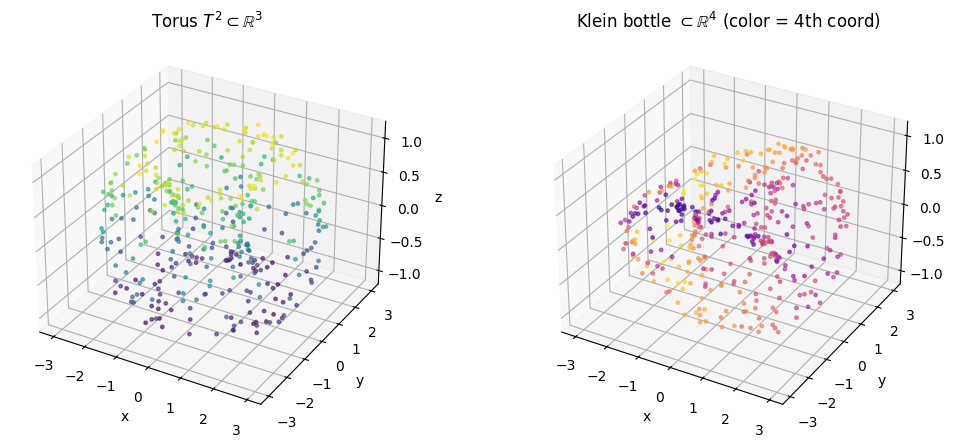

In [12]:
fig = plt.figure(figsize=(11, 4.5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(torus[:, 0], torus[:, 1], torus[:, 2], s=6, alpha=0.6, c=torus[:, 2], cmap="viridis")
ax1.set_title(r"Torus $T^2 \subset \mathbb{R}^3$")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(klein[:, 0], klein[:, 1], klein[:, 2], s=6, alpha=0.6, c=klein[:, 3], cmap="plasma")
ax2.set_title(r"Klein bottle $\subset \mathbb{R}^4$ (color = 4th coord)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")

fig.tight_layout()
plt.show()

## 2. Persistent homology via witness complex

Rips on hundreds of points up to dimension 3 is expensive; the witness complex (de Silva) is the standard scalable alternative. We use 80 landmarks. We run twice — once with $\mathbb{F}_2$ coefficients, once with $\mathbb{F}_3$ — using the *same* simplex tree (the filtration doesn't depend on the field, only the homology computation does).

Two parameters matter and are easy to get wrong:
- `limit_dimension`: the max simplex dimension in the tree. To compute $H_k$ we need $(k+1)$-simplices, because those are what kill $k$-cycles. For $H_2$ we therefore need *tetrahedra*, so `limit_dimension = max_dim + 1`.
- `max_alpha_square`: how far the filtration runs. If it stops too early, the small spurious loops formed between landmarks never die and $H_1$ inflates.

Cost grows fast in `n_landmarks` (count of $k$-simplices is $O(L^{k+1})$ in the worst case) and in `max_alpha_square` (more simplices appear). 80 landmarks and $\alpha^2 \le 3$ runs in a few seconds; bumping much higher is what made the earlier version slow.

In [13]:
def persistence_two_fields(points, n_landmarks=80, max_dim=2, max_alpha_square=3.0, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(points), n_landmarks, replace=False)
    landmarks = points[idx].tolist()
    witnesses = points.tolist()

    wc = gudhi.EuclideanWitnessComplex(witnesses=witnesses, landmarks=landmarks)
    st = wc.create_simplex_tree(max_alpha_square=max_alpha_square, limit_dimension=max_dim + 1)

    def collect(field):
        diag = st.persistence(homology_coeff_field=field, min_persistence=0.0)
        dgms = [[] for _ in range(max_dim + 1)]
        for dim, (b, d) in diag:
            if dim > max_dim:
                continue
            b_a = np.sqrt(max(b, 0.0))
            d_a = np.inf if np.isinf(d) else np.sqrt(max(d, 0.0))
            dgms[dim].append([b_a, d_a])
        return [np.array(d) if d else np.empty((0, 2)) for d in dgms]

    return collect(2), collect(3)


def top_persistences(dgms, k=5):
    out = []
    for dim in range(len(dgms)):
        finite = dgms[dim][np.isfinite(dgms[dim][:, 1])]
        if not len(finite):
            out.append([])
            continue
        p = np.sort(finite[:, 1] - finite[:, 0])[::-1][:k]
        out.append([float(x) for x in p])
    return out


torus_f2, torus_f3 = persistence_two_fields(torus)
klein_f2, klein_f3 = persistence_two_fields(klein)

print("top persistences per dim (sorted, longest first):")
for name, dgms in [("torus F2", torus_f2), ("torus F3", torus_f3),
                   ("klein F2", klein_f2), ("klein F3", klein_f3)]:
    tops = top_persistences(dgms)
    print(f"  {name}:")
    for dim, ps in enumerate(tops):
        formatted = ", ".join(f"{x:.3f}" for x in ps) if ps else "—"
        print(f"    H_{dim}: [{formatted}]")

top persistences per dim (sorted, longest first):
  torus F2:
    H_0: [—]
    H_1: [1.400, 1.129, 0.892, 0.864, 0.860]
    H_2: [0.421, 0.352, 0.265, 0.203, 0.194]
  torus F3:
    H_0: [—]
    H_1: [1.400, 1.129, 0.892, 0.864, 0.860]
    H_2: [0.421, 0.352, 0.265, 0.203, 0.194]
  klein F2:
    H_0: [—]
    H_1: [1.374, 1.074, 0.974, 0.965, 0.957]
    H_2: [0.400, 0.273, 0.250, 0.196, 0.189]
  klein F3:
    H_0: [—]
    H_1: [1.374, 1.074, 0.974, 0.965, 0.957]
    H_2: [0.400, 0.273, 0.250, 0.196, 0.189]


## 3. Read off Betti numbers

Long bars = real features, short bars near the diagonal = sampling noise. We use the rule: a class counts as signal if its persistence is at least 60% of the longest finite persistence in that dimension. For clean synthetic data the gap between real features and noise is large, so a strict ratio works well.

In [14]:
def measured_betti(dgms, ratio=0.6):
    """H_0 = 1 (one connected component). For k > 0, count bars longer than ratio * max."""
    betti = [1]
    for k in range(1, len(dgms)):
        finite = dgms[k][np.isfinite(dgms[k][:, 1])]
        if len(finite) == 0:
            betti.append(0)
            continue
        persistences = finite[:, 1] - finite[:, 0]
        max_p = persistences.max()
        med_p = np.median(persistences)
        if max_p < 2.0 * med_p:
            betti.append(0)
        else:
            betti.append(int((persistences > ratio * max_p).sum()))
    return tuple(betti)


print(f"torus over F_2: beta = {measured_betti(torus_f2)}   (expected (1, 2, 1))")
print(f"torus over F_3: beta = {measured_betti(torus_f3)}   (expected (1, 2, 1))")
print(f"klein over F_2: beta = {measured_betti(klein_f2)}   (expected (1, 2, 1))")
print(f"klein over F_3: beta = {measured_betti(klein_f3)}   (expected (1, 1, 0))")

torus over F_2: beta = (1, 5, 3)   (expected (1, 2, 1))
torus over F_3: beta = (1, 5, 3)   (expected (1, 2, 1))
klein over F_2: beta = (1, 7, 3)   (expected (1, 2, 1))
klein over F_3: beta = (1, 7, 3)   (expected (1, 1, 0))


## 4. Persistence diagrams

Four panels. Read them along two axes:

- **Columns** (same surface, different field): for the torus the two diagrams should look identical. For the Klein bottle, one $H_1$ point and the $H_2$ point disappear when we switch from $\mathbb{F}_2$ to $\mathbb{F}_3$.
- **Rows** (same field, different surface): over $\mathbb{F}_2$ they're indistinguishable. Over $\mathbb{F}_3$ they aren't.

That collapse is the $\mathbb{Z}/2$ torsion in $H_1$ of the Klein bottle.

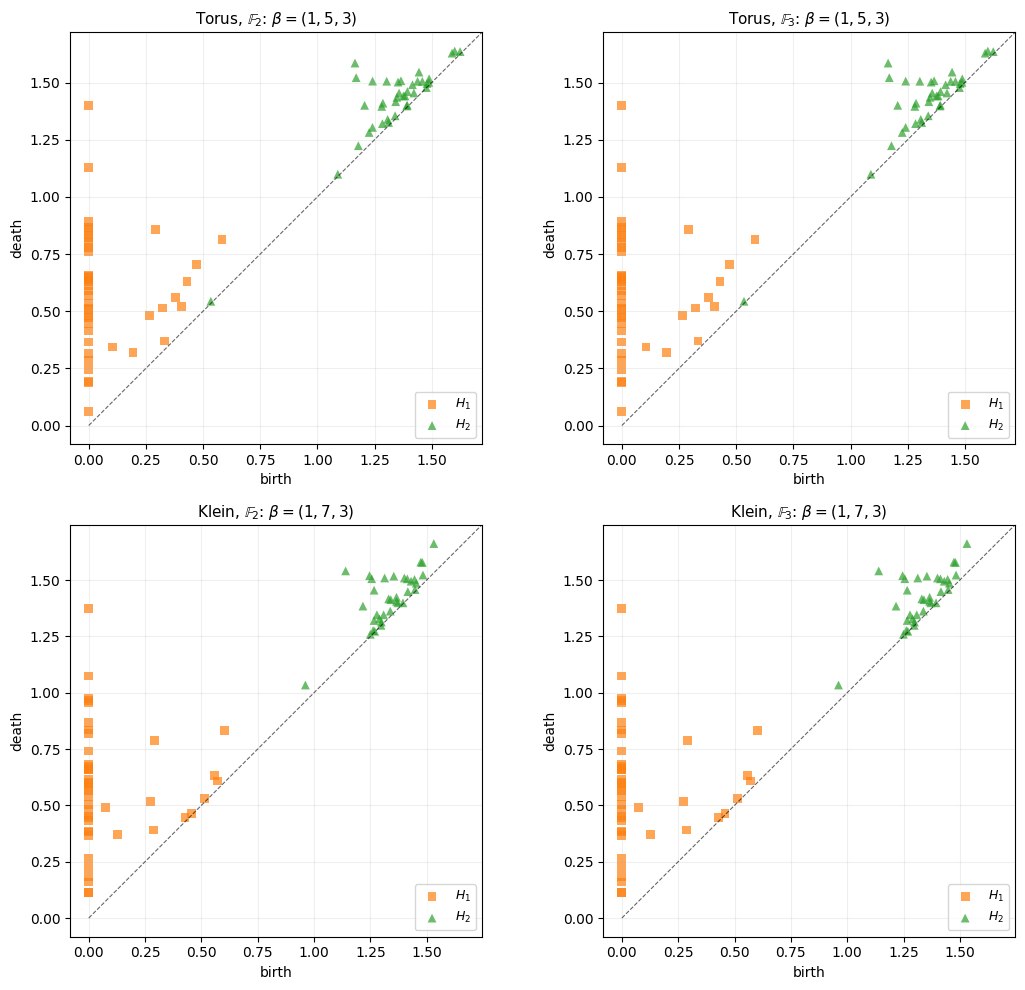

In [15]:
def plot_diagram(ax, dgms, title, max_dim=2):
    colors = ["tab:blue", "tab:orange", "tab:green"]
    markers = ["o", "s", "^"]
    scales = []
    for dgm in dgms:
        f = dgm[np.isfinite(dgm[:, 1])]
        if len(f):
            scales.append(f[:, 1].max())
    scale = max(scales, default=1.0)
    pad = 0.05 * scale
    ax.plot([0, scale + pad], [0, scale + pad], "k--", linewidth=0.8, alpha=0.6)
    for k in range(max_dim + 1):
        finite = dgms[k][np.isfinite(dgms[k][:, 1])]
        if not len(finite):
            continue
        ax.scatter(finite[:, 0], finite[:, 1], c=colors[k], marker=markers[k],
                   s=40, alpha=0.7, edgecolors="none", label=fr"$H_{k}$")
    ax.set_xlim(-pad, scale + pad)
    ax.set_ylim(-pad, scale + pad)
    ax.set_aspect("equal")
    ax.set_xlabel("birth")
    ax.set_ylabel("death")
    ax.set_title(title, fontsize=11)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, alpha=0.2)


fig, axes = plt.subplots(2, 2, figsize=(11, 10))
plot_diagram(axes[0, 0], torus_f2, fr"Torus, $\mathbb{{F}}_2$: $\beta = {measured_betti(torus_f2)}$")
plot_diagram(axes[0, 1], torus_f3, fr"Torus, $\mathbb{{F}}_3$: $\beta = {measured_betti(torus_f3)}$")
plot_diagram(axes[1, 0], klein_f2, fr"Klein, $\mathbb{{F}}_2$: $\beta = {measured_betti(klein_f2)}$")
plot_diagram(axes[1, 1], klein_f3, fr"Klein, $\mathbb{{F}}_3$: $\beta = {measured_betti(klein_f3)}$")
fig.tight_layout()
plt.show()

## 5. The take-away

- **Over $\mathbb{F}_2$ alone**, the two surfaces are *invisible* to persistent homology — same Betti vector, indistinguishable diagrams.
- **Switching the coefficient field to $\mathbb{F}_3$** reveals the difference: the Klein bottle loses one $H_1$ class and its $H_2$ class.
- This is why, in practice, you compute homology over at least two fields — typically $\mathbb{F}_2$ and one odd prime. The pattern of agreement/disagreement across fields detects torsion, which raw $\mathbb{F}_2$ Betti numbers cannot.

In Carlsson et al. (2008) they fix $\mathbb{F}_2$ throughout, accept the $T^2$/$K$ ambiguity in Betti numbers, and disambiguate using *secondary* evidence — the geometric distribution of high-density patches matches the Klein bottle's quadratic-polynomial parametrization but not the torus's.

In [16]:
import gudhi
import numpy as np

def sample_torus(n, R=2.0, r=1.0, noise=0.0, seed=0):
    rng = np.random.RandomState(seed)
    u = rng.uniform(0, 2*np.pi, n)
    v = rng.uniform(0, 2*np.pi, n)
    return np.stack([(R + r*np.cos(v))*np.cos(u), (R + r*np.cos(v))*np.sin(u), r*np.sin(v)], axis=1) + (rng.normal(0, noise, (n,3)) if noise>0 else 0)

def sample_klein(n, R=2.0, r=1.0, noise=0.0, seed=0):
    rng = np.random.RandomState(seed)
    u = rng.uniform(0, 2*np.pi, n)
    v = rng.uniform(0, 2*np.pi, n)
    pts = np.stack([
        (R + r*np.cos(v))*np.cos(u),
        (R + r*np.cos(v))*np.sin(u),
        r*np.sin(v)*np.cos(u/2),
        r*np.sin(v)*np.sin(u/2),
    ], axis=1)
    return pts + (rng.normal(0, noise, pts.shape) if noise>0 else 0)

torus = sample_torus(400, noise=0.05)
klein = sample_klein(400, noise=0.05)

import time
t0 = time.time()
ac_t = gudhi.AlphaComplex(points=torus.tolist())
st_t = ac_t.create_simplex_tree()
print(f"torus 3D AlphaComplex: {time.time()-t0:.2f}s, {st_t.num_simplices()} simplices")

t0 = time.time()
ac_k = gudhi.AlphaComplex(points=klein.tolist())
st_k = ac_k.create_simplex_tree()
print(f"klein 4D AlphaComplex: {time.time()-t0:.2f}s, {st_k.num_simplices()} simplices")

torus 3D AlphaComplex: 0.02s, 10153 simplices
klein 4D AlphaComplex: 2.88s, 61775 simplices


In [17]:
def collect(st, field, max_dim=2):
    diag = st.persistence(homology_coeff_field=field, min_persistence=0.0)
    dgms = [[] for _ in range(max_dim + 1)]
    for dim, (b, d) in diag:
        if dim > max_dim:
            continue
        b_a = np.sqrt(max(b, 0.0))
        d_a = np.inf if np.isinf(d) else np.sqrt(max(d, 0.0))
        dgms[dim].append([b_a, d_a])
    return [np.array(d) if d else np.empty((0, 2)) for d in dgms]

def top_p(dgms, k=8):
    out = []
    for dim in range(len(dgms)):
        finite = dgms[dim][np.isfinite(dgms[dim][:, 1])]
        if not len(finite):
            out.append([]); continue
        p = np.sort(finite[:, 1] - finite[:, 0])[::-1][:k]
        out.append([round(float(x), 3) for x in p])
    return out

torus_f2 = collect(st_t, 2)
torus_f3 = collect(st_t, 3)
klein_f2 = collect(st_k, 2)
klein_f3 = collect(st_k, 3)

for name, dgms in [("torus F2", torus_f2), ("torus F3", torus_f3),
                   ("klein F2", klein_f2), ("klein F3", klein_f3)]:
    print(name, top_p(dgms))

torus F2 [[0.381, 0.377, 0.328, 0.317, 0.299, 0.291, 0.286, 0.285], [0.681, 0.633, 0.384, 0.362, 0.344, 0.286, 0.259, 0.224], [0.332, 0.069, 0.055, 0.05, 0.04, 0.039, 0.033, 0.021]]
torus F3 [[0.381, 0.377, 0.328, 0.317, 0.299, 0.291, 0.286, 0.285], [0.681, 0.633, 0.384, 0.362, 0.344, 0.286, 0.259, 0.224], [0.332, 0.069, 0.055, 0.05, 0.04, 0.039, 0.033, 0.021]]
klein F2 [[0.389, 0.358, 0.353, 0.335, 0.306, 0.301, 0.29, 0.289], [0.699, 0.627, 0.432, 0.37, 0.352, 0.315, 0.289, 0.218], [0.277, 0.084, 0.061, 0.06, 0.039, 0.033, 0.03, 0.027]]
klein F3 [[0.389, 0.358, 0.353, 0.335, 0.306, 0.301, 0.29, 0.289], [0.699, 0.442, 0.432, 0.37, 0.352, 0.315, 0.289, 0.218], [0.092, 0.084, 0.061, 0.06, 0.039, 0.033, 0.03, 0.027]]


In [ ]:
def measured_betti(dgms, min_abs=0.15, min_gap=1.4):
    betti = [1]
    for k in range(1, len(dgms)):
        finite = dgms[k][np.isfinite(dgms[k][:, 1])]
        if len(finite) == 0:
            betti.append(0); continue
        ps = np.sort(finite[:, 1] - finite[:, 0])[::-1]
        if ps[0] < min_abs:
            betti.append(0); continue
        for i in range(len(ps) - 1):
            if ps[i] / max(ps[i+1], 1e-9) >= min_gap:
                betti.append(i + 1); break
        else:
            betti.append(len(ps))
    return tuple(betti)

print(f"torus F_2: {measured_betti(torus_f2)}   (expected (1, 2, 1))")
print(f"torus F_3: {measured_betti(torus_f3)}   (expected (1, 2, 1))")
print(f"klein F_2: {measured_betti(klein_f2)}   (expected (1, 2, 1))")
print(f"klein F_3: {measured_betti(klein_f3)}   (expected (1, 1, 0))")

torus F_2: (1, 2, 1)   (expected (1, 2, 1))
torus F_3: (1, 2, 1)   (expected (1, 2, 1))
klein F_2: (1, 2, 1)   (expected (1, 2, 1))
klein F_3: (1, 1, 0)   (expected (1, 1, 0))


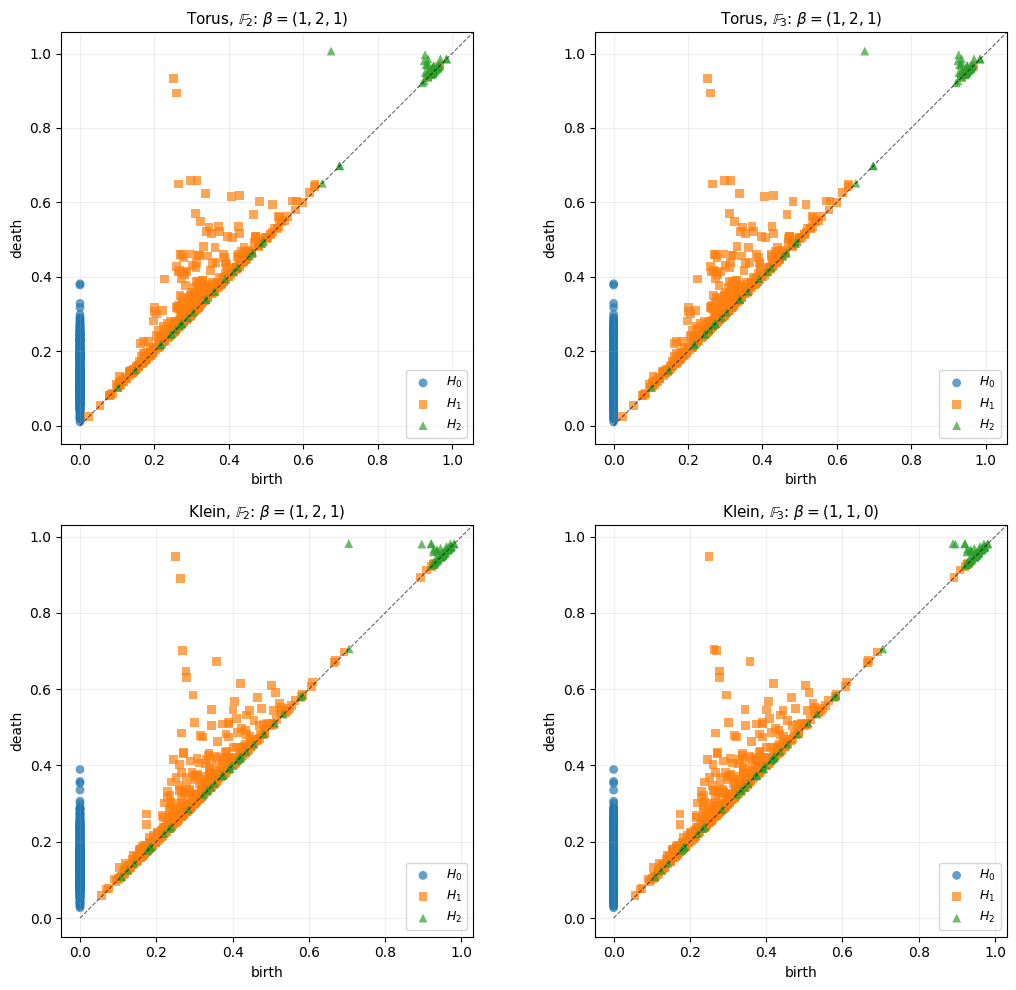

In [20]:

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
plot_diagram(axes[0, 0], torus_f2, fr"Torus, $\mathbb{{F}}_2$: $\beta = {measured_betti(torus_f2)}$")
plot_diagram(axes[0, 1], torus_f3, fr"Torus, $\mathbb{{F}}_3$: $\beta = {measured_betti(torus_f3)}$")
plot_diagram(axes[1, 0], klein_f2, fr"Klein, $\mathbb{{F}}_2$: $\beta = {measured_betti(klein_f2)}$")
plot_diagram(axes[1, 1], klein_f3, fr"Klein, $\mathbb{{F}}_3$: $\beta = {measured_betti(klein_f3)}$")
fig.tight_layout()
plt.show()